In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt

torch.manual_seed(123)
np.random.seed(123)

# -----------------------------
# Simulation settings
# -----------------------------
Nsub = 10
K = 2
D = 5
sigma_obs = 0.2

theta_true = np.array([0.5, 1.0])
mu0_true = np.array([0.0, 1.0])
sigma0_true = np.array([0.3, 0.4])

Lambda_true = np.array([
    [1.0, 0.5],
    [0.3, 1.2],
    [0.0, 0.8],
    [1.0, 0.3],
    [0.2, 0.7]
])

y_list, t_list, x_list = [], [], []

for i in range(Nsub):
    T_i = np.random.randint(5, 11)
    dt_i = np.random.uniform(0.5, 1.5, size=T_i - 1)
    t_i = np.concatenate([[0.0], np.cumsum(dt_i)])

    x_i = np.zeros((T_i, K))
    x_i[0] = np.random.normal(mu0_true, sigma0_true)

    for n in range(1, T_i):
        phi = np.exp(-theta_true * (t_i[n] - t_i[n - 1]))
        ou_sd = sigma0_true * np.sqrt((1 - phi ** 2) / (2 * theta_true))
        mu = mu0_true + phi * (x_i[n - 1] - mu0_true)
        # x_i[n] = np.random.normal(mu, ou_sd)
        x_i[n] = mu 

    y_i = x_i @ Lambda_true.T + np.random.normal(0, sigma_obs, size=(T_i, D))

    x_list.append(x_i)
    y_list.append(y_i)
    t_list.append(t_i)


In [2]:
# Convert data to torch
y_torch = [torch.tensor(y, dtype=torch.float32) for y in y_list]
t_torch = [torch.tensor(t, dtype=torch.float32) for t in t_list]


In [3]:
import numpy as np
import matplotlib.pyplot as plt
import torch

def estimate_latent_trajectory(model, i, t_torch_i):
    """
    Deterministic latent propagation for one subject and one model
    """
    x_est = []
    x_prev = model.x0[i]

    x_est.append(x_prev)

    for n in range(1, len(t_torch_i)):
        dt = t_torch_i[n] - t_torch_i[n - 1]
        x_next = model.propagate_latent(x_prev, dt)
        x_est.append(x_next)
        x_prev = x_next

    return torch.stack(x_est, dim=0)  # (T_i, K)


In [4]:
import torch
import torch.nn as nn
import torch.optim as optim


class DeterministicLatentODE(nn.Module):
    def __init__(self, K, D, Nsub, Lambda_true):
        super().__init__()

        self.K = K
        self.D = D
        self.Nsub = Nsub

        # -----------------------------
        # Known observation matrix
        # -----------------------------
        self.register_buffer(
            "Lambda",
            torch.tensor(Lambda_true, dtype=torch.float32)
        )

        # -----------------------------
        # Parameters to learn
        # -----------------------------
        self.theta = nn.Parameter(torch.ones(K) * 0.3)     # decay rates
        self.mu0   = nn.Parameter(torch.zeros(K))          # global mean
        self.x0    = nn.Parameter(torch.randn(Nsub, K))    # initial latent states
        self.log_sigma_obs = nn.Parameter(torch.tensor(-1.0))

    def propagate_latent(self, x_prev, dt):
        """
        x_prev : (K,)
        dt     : scalar
        """
        phi = torch.exp(-self.theta * dt)
        x_next = self.mu0 + phi * (x_prev - self.mu0)
        return x_next

    def forward(self, y_list, t_list):
        sigma_obs2 = torch.exp(self.log_sigma_obs)

        total_nll = 0.0

        for i, (y_i, t_i) in enumerate(zip(y_list, t_list)):
            T_i = y_i.shape[0]

            # latent trajectory
            x_pred = []
            x_prev = self.x0[i]
            x_pred.append(x_prev)

            for n in range(1, T_i):
                dt = t_i[n] - t_i[n - 1]
                x_next = self.propagate_latent(x_prev, dt)
                x_pred.append(x_next)
                x_prev = x_next

            x_pred = torch.stack(x_pred, dim=0)   # (T_i, K)

            # observation prediction
            y_hat = x_pred @ self.Lambda.T        # (T_i, D)

            # Gaussian NLL
            resid = y_i - y_hat
            total_nll += (
                resid.pow(2).sum() / (2 * sigma_obs2)
                + 0.5 * y_i.numel() * torch.log(sigma_obs2)
            )

        # weak regularization
        total_nll += 1e-3 * self.x0.pow(2).sum()

        return total_nll


In [5]:
def train_one_run(y_torch, t_torch, K, D, Nsub, Lambda_true,
                  lr=1e-2, n_epochs=3000, seed=None):

    if seed is not None:
        torch.manual_seed(seed)

    model = DeterministicLatentODE(
        K=K,
        D=D,
        Nsub=Nsub,
        Lambda_true=Lambda_true
    )
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    loss_history = []

    for epoch in range(n_epochs):
        optimizer.zero_grad()
        loss = model(y_torch, t_torch)
        loss.backward()
        optimizer.step()

        loss_history.append(loss.item())

    return model, np.array(loss_history)


In [6]:
n_runs = 10

models = []
loss_curves = []

for r in range(n_runs):
    model_r, loss_r = train_one_run(
        y_torch, t_torch,
        K=K, D=D, Nsub=Nsub, Lambda_true=Lambda_true,
        seed=100 + r
    )
    models.append(model_r)
    loss_curves.append(loss_r)

loss_curves = np.stack(loss_curves)  # (n_runs, n_epochs)

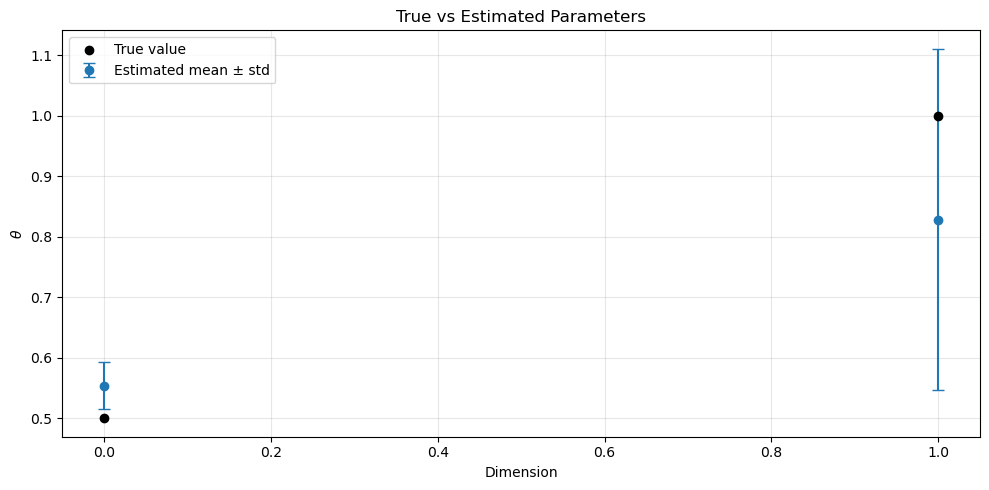

In [7]:
with torch.no_grad():
    theta_est_runs = []

    for model in models:
        theta_est = model.theta.cpu().numpy()
        theta_est_runs.append(theta_est)

    theta_est_runs = np.stack(theta_est_runs)  # (n_runs, K)

    # Mean and variance
    theta_mean = theta_est_runs.mean(axis=0)
    theta_std  = theta_est_runs.std(axis=0)


    # Assume these are given
    # theta_true: shape (D,)
    # theta_mean: shape (D,)
    # theta_std: shape (D,)

    K = len(theta_true)
    idx = np.arange(K)

    plt.figure(figsize=(10, 5))

    plt.errorbar(
        idx,
        theta_mean,
        yerr=theta_std,
        fmt='o',
        capsize=4,
        label='Estimated mean ± std'
    )

    plt.scatter(
        idx,
        theta_true,
        color='black',
        zorder=3,
        label='True value'
    )

    plt.xlabel('Dimension')
    plt.ylabel(r'$\theta$')
    plt.title('True vs Estimated Parameters')
    plt.legend()
    plt.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()





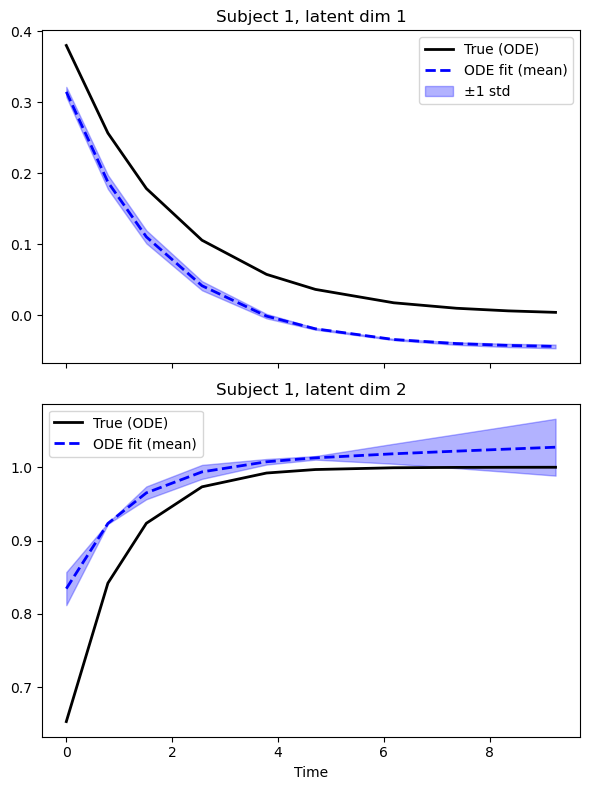

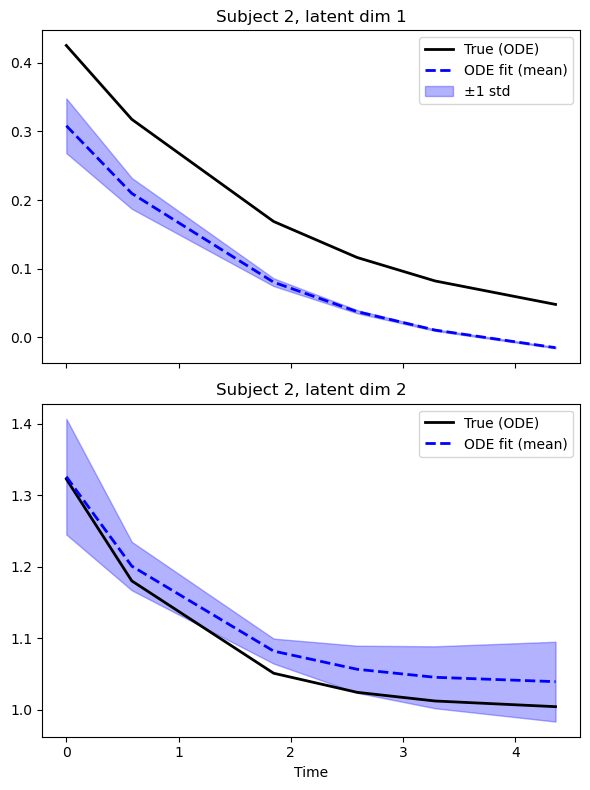

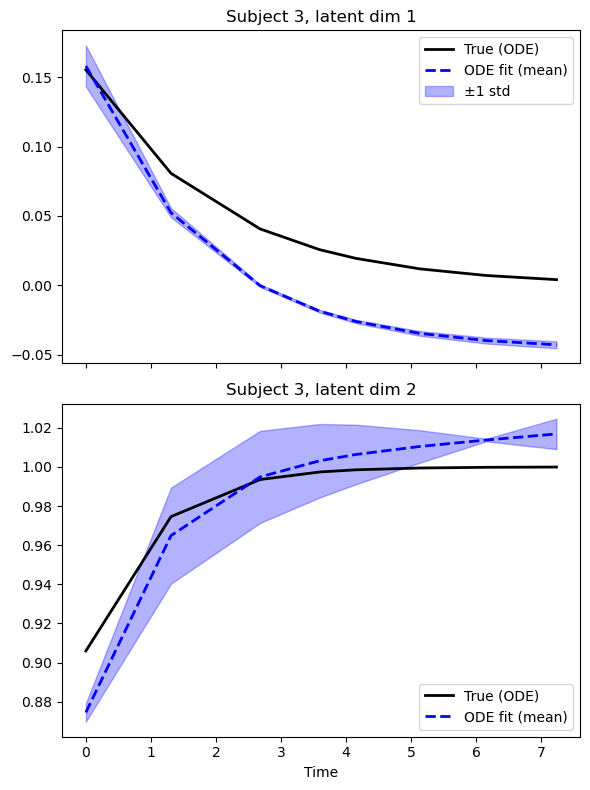

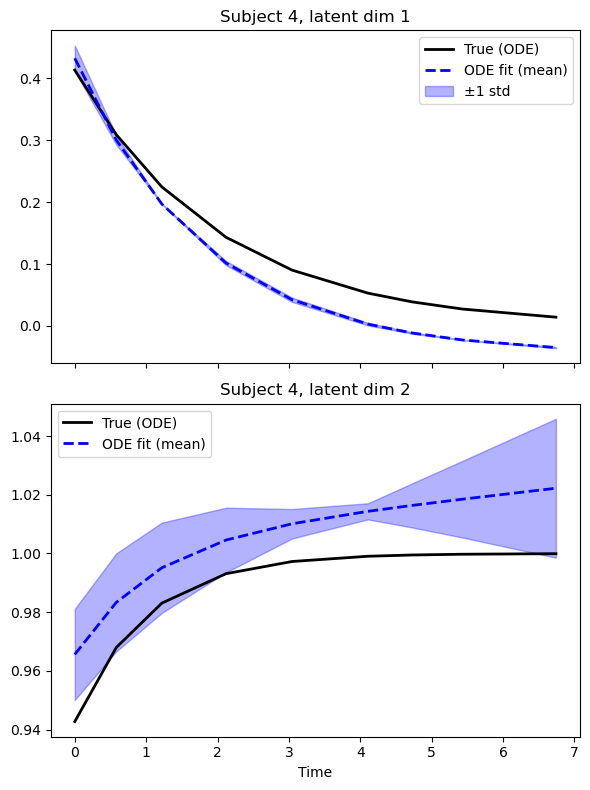

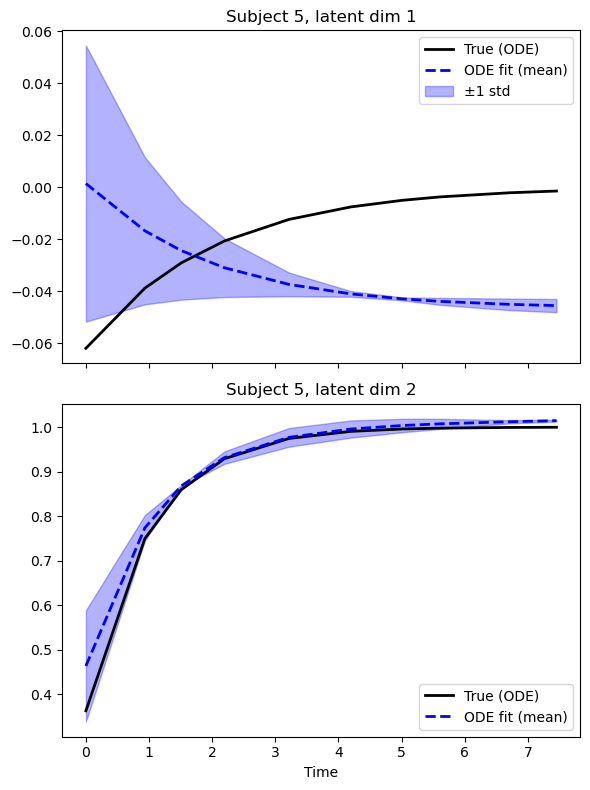

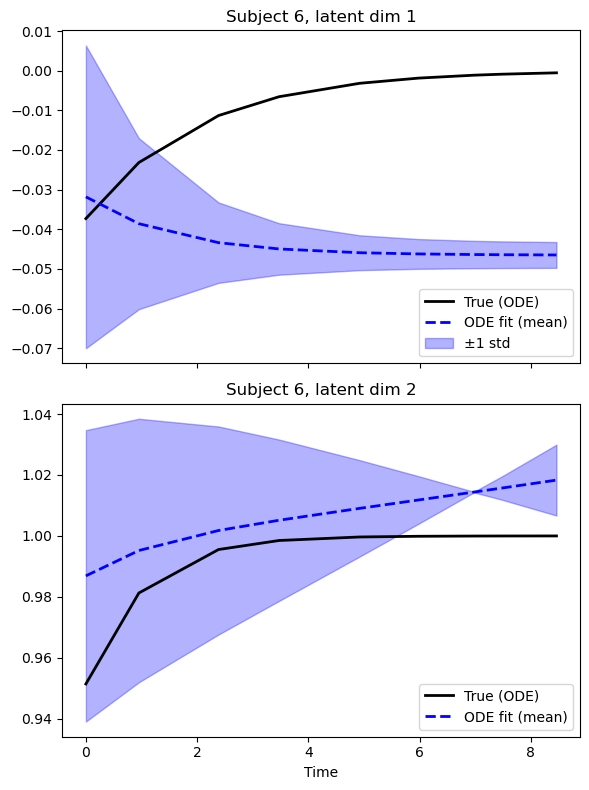

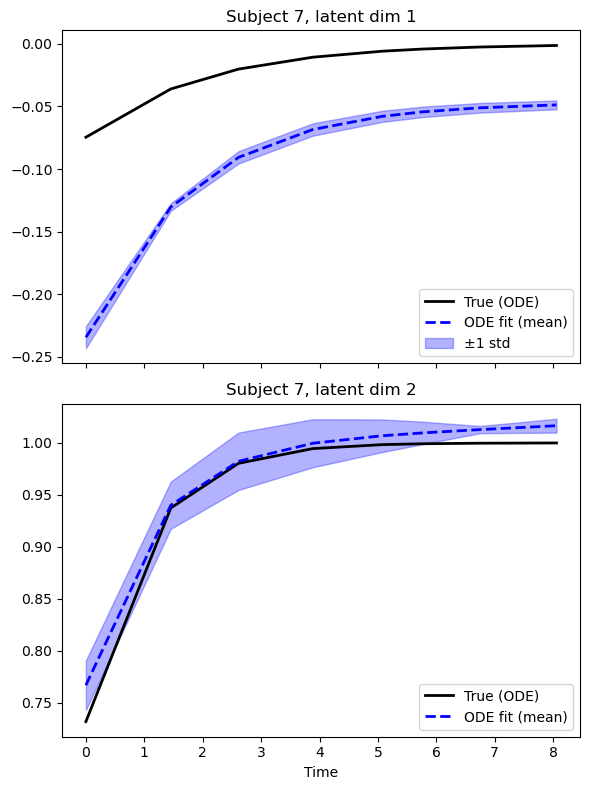

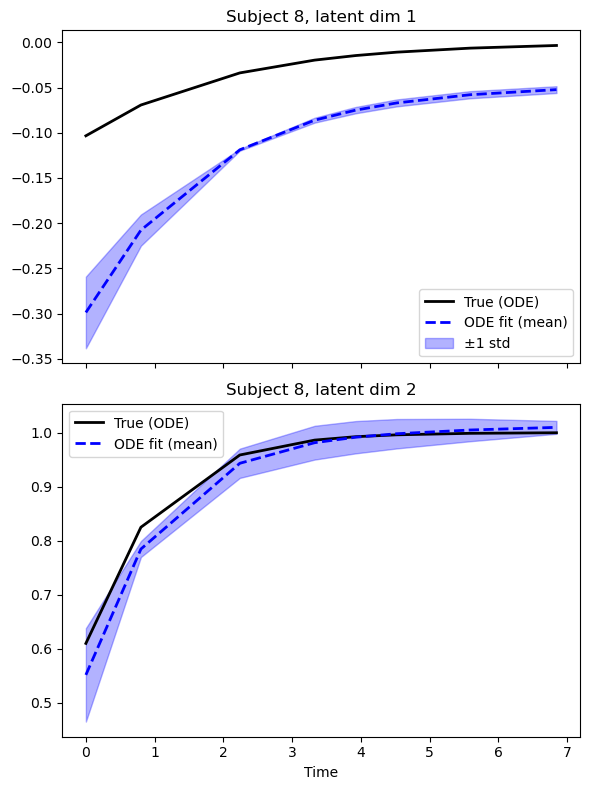

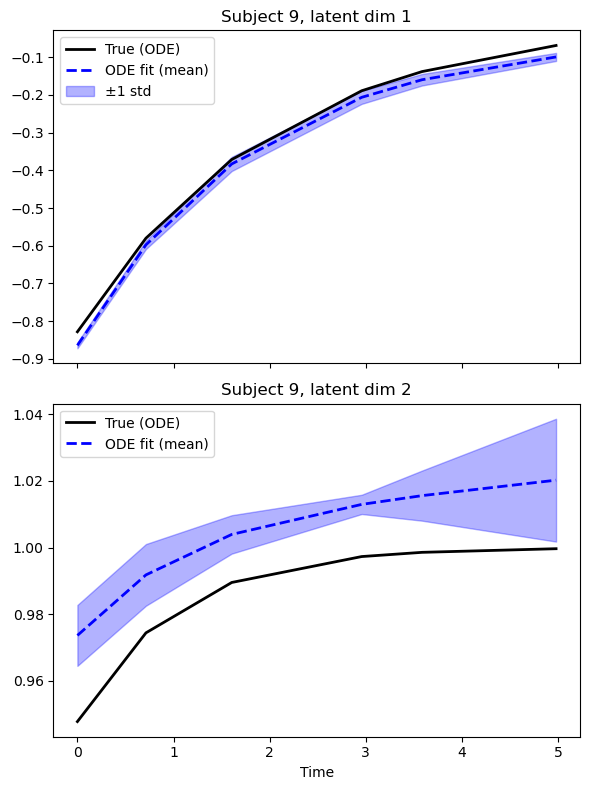

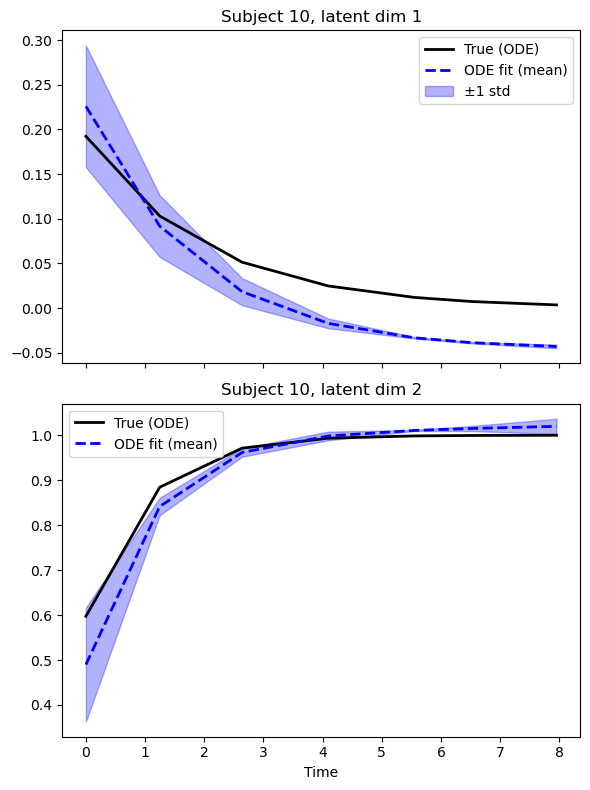

In [8]:
with torch.no_grad():
    for i in range(Nsub):
        T_i = len(t_list[i])
        t_i = t_list[i]

        # Collect trajectories from all runs
        x_est_runs = []
        theta_est_runs = []

        for model in models:
            x_est_i = estimate_latent_trajectory(
                model,
                i,
                t_torch[i]
            )
            x_est_runs.append(x_est_i)
            theta_est_i = model.theta.cpu().numpy()
            theta_est_runs.append(theta_est_i)
        # Shape: (n_runs, T_i, K)
        x_est_runs = torch.stack(x_est_runs).cpu().numpy()
        theta_est_runs = np.stack(theta_est_runs)  # (n_runs, K)

        # Mean and variance
        x_mean = x_est_runs.mean(axis=0)
        x_std  = x_est_runs.std(axis=0)
        theta_mean = theta_est_runs.mean(axis=0)
        theta_std  = theta_est_runs.std(axis=0)

        x_true = x_list[i]
        theta_true_i = theta_true

        fig, axes = plt.subplots(K, 1, figsize=(6, 4 * K), sharex=True)

        if K == 1:
            axes = [axes]

        for k in range(K):
            # True latent (OU)
            axes[k].plot(
                t_i,
                x_true[:, k],
                'k-',
                lw=2,
                label="True (ODE)"
            )

            # Mean estimate
            axes[k].plot(
                t_i,
                x_mean[:, k],
                'b--',
                lw=2,
                label="ODE fit (mean)"
            )

            # Variance / CI shading
            axes[k].fill_between(
                t_i,
                x_mean[:, k] - x_std[:, k],
                x_mean[:, k] + x_std[:, k],
                color='blue',
                alpha=0.3,
                label="±1 std" if k == 0 else None
            )

            axes[k].set_title(
                f"Subject {i+1}, latent dim {k+1}"
            )
            axes[k].legend()

        axes[-1].set_xlabel("Time")
        plt.tight_layout()
        plt.show()



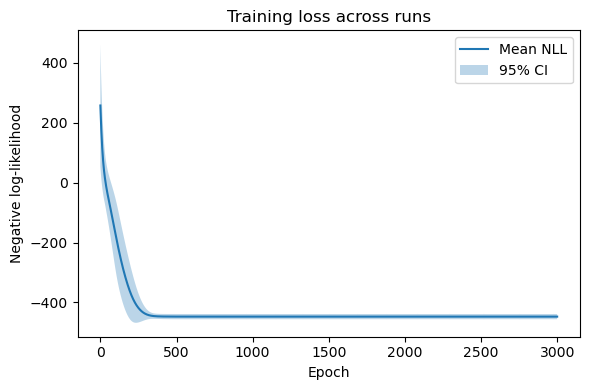

In [9]:
import matplotlib.pyplot as plt

mean_loss = loss_curves.mean(axis=0)
std_loss = loss_curves.std(axis=0)

plt.figure(figsize=(6,4))
plt.plot(mean_loss, label="Mean NLL")
plt.fill_between(
    np.arange(len(mean_loss)),
    mean_loss - 1.96 * std_loss,
    mean_loss + 1.96 * std_loss,
    alpha=0.3,
    label="95% CI"
)
plt.xlabel("Epoch")
plt.ylabel("Negative log-likelihood")
plt.legend()
plt.title("Training loss across runs")
plt.tight_layout()
plt.show()


In [10]:
import torch
import torch.nn as nn
import torch.optim as optim


class DeterministicLatentODE_NMF(nn.Module):
    def __init__(self, K, D, Nsub):
        super().__init__()

        self.K = K
        self.D = D
        self.Nsub = Nsub

        # -----------------------------
        # Latent dynamics parameters
        # -----------------------------
        self.theta = nn.Parameter(torch.ones(K) * 0.3)
        self.mu0   = nn.Parameter(torch.zeros(K))
        self.x0    = nn.Parameter(torch.randn(Nsub, K))

        # -----------------------------
        # NMF-style nonnegative Lambda
        # -----------------------------
        self.Lambda_raw = nn.Parameter(torch.randn(D, K))
        self.log_sigma_obs = nn.Parameter(torch.tensor(-1.0))

    def Lambda(self):
        # smooth, strictly positive
        return torch.nn.functional.softplus(self.Lambda_raw)

    def propagate_latent(self, x_prev, dt):
        phi = torch.exp(-self.theta * dt)
        x_next = self.mu0 + phi * (x_prev - self.mu0)
        return x_next

    def forward(self, y_list, t_list):
        sigma_obs2 = torch.exp(self.log_sigma_obs)
        Lambda = self.Lambda()

        total_nll = 0.0

        for i, (y_i, t_i) in enumerate(zip(y_list, t_list)):
            T_i = y_i.shape[0]

            x_pred = []
            x_prev = self.x0[i]
            x_pred.append(x_prev)

            for n in range(1, T_i):
                dt = t_i[n] - t_i[n - 1]
                x_next = self.propagate_latent(x_prev, dt)
                x_pred.append(x_next)
                x_prev = x_next

            x_pred = torch.stack(x_pred, dim=0)      # (T_i, K)
            y_hat = x_pred @ Lambda.T               # (T_i, D)

            resid = y_i - y_hat
            total_nll += (
                resid.pow(2).sum() / (2 * sigma_obs2)
                + 0.5 * y_i.numel() * torch.log(sigma_obs2)
            )

        # Regularization (important for identifiability)
        total_nll += 1e-3 * self.x0.pow(2).sum()
        total_nll += 1e-3 * Lambda.pow(2).sum()

        return total_nll



In [11]:
def train_one_run(y_torch, t_torch, K, D, Nsub,
                  lr=1e-2, n_epochs=3000, seed=None):

    if seed is not None:
        torch.manual_seed(seed)

    model = DeterministicLatentODE_NMF(K=K, D=D, Nsub=Nsub)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    loss_history = []

    for epoch in range(n_epochs):
        optimizer.zero_grad()
        loss = model(y_torch, t_torch)
        loss.backward()
        optimizer.step()

        loss_history.append(loss.item())

    return model, np.array(loss_history)


In [12]:
n_runs = 10

models = []
loss_curves = []

for r in range(n_runs):
    model_r, loss_r = train_one_run(
        y_torch, t_torch,
        K=K, D=D, Nsub=Nsub,
        seed=100 + r
    )
    models.append(model_r)
    loss_curves.append(loss_r)

loss_curves = np.stack(loss_curves)  # (n_runs, n_epochs)


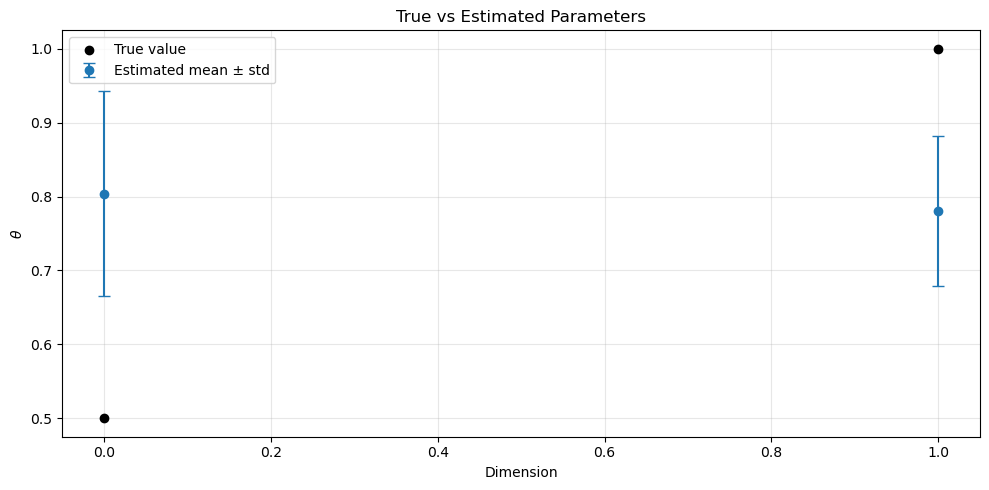

In [13]:
with torch.no_grad():
    theta_est_runs = []

    for model in models:
        theta_est = model.theta.cpu().numpy()
        theta_est_runs.append(theta_est)

    theta_est_runs = np.stack(theta_est_runs)  # (n_runs, K)

    # Mean and variance
    theta_mean = theta_est_runs.mean(axis=0)
    theta_std  = theta_est_runs.std(axis=0)


    # Assume these are given
    # theta_true: shape (D,)
    # theta_mean: shape (D,)
    # theta_std: shape (D,)

    K = len(theta_true)
    idx = np.arange(K)

    plt.figure(figsize=(10, 5))

    plt.errorbar(
        idx,
        theta_mean,
        yerr=theta_std,
        fmt='o',
        capsize=4,
        label='Estimated mean ± std'
    )

    plt.scatter(
        idx,
        theta_true,
        color='black',
        zorder=3,
        label='True value'
    )

    plt.xlabel('Dimension')
    plt.ylabel(r'$\theta$')
    plt.title('True vs Estimated Parameters')
    plt.legend()
    plt.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()





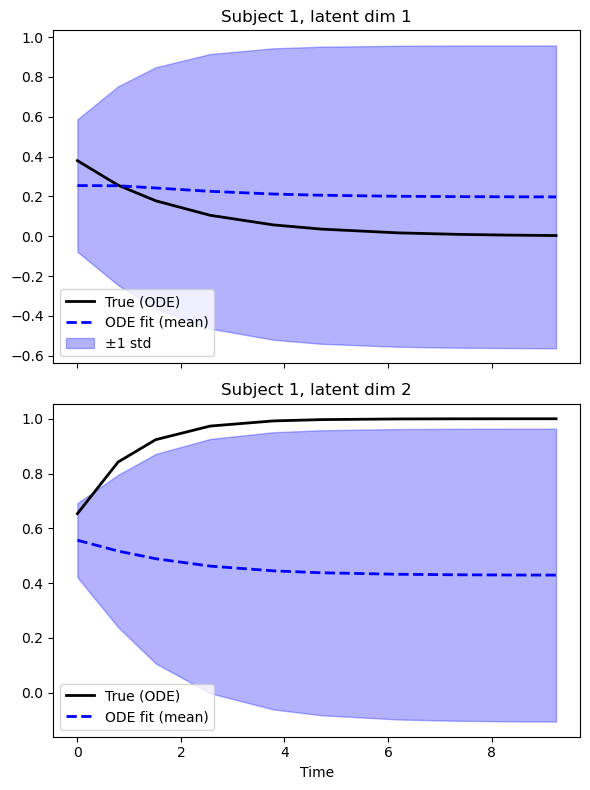

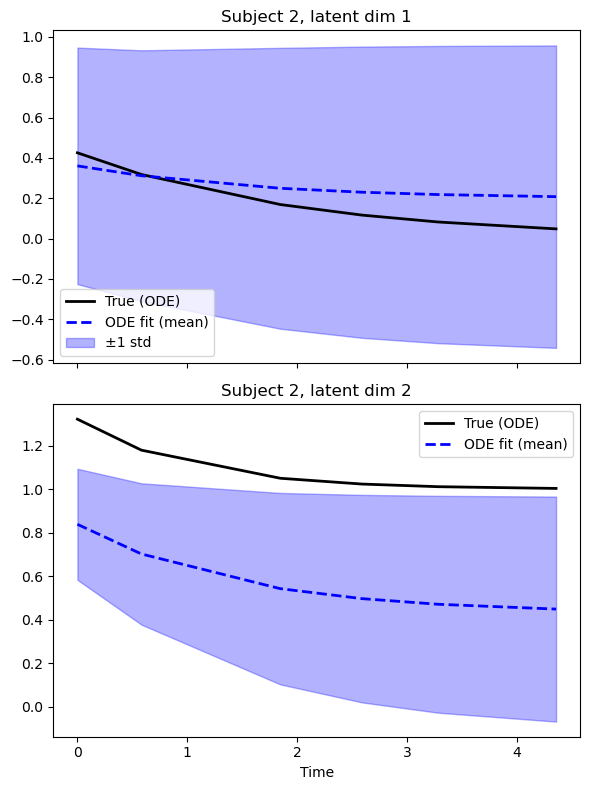

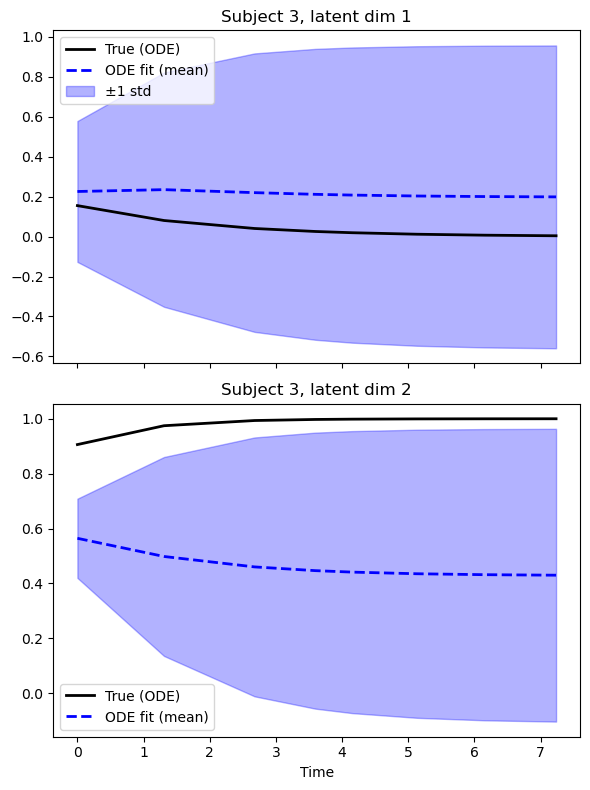

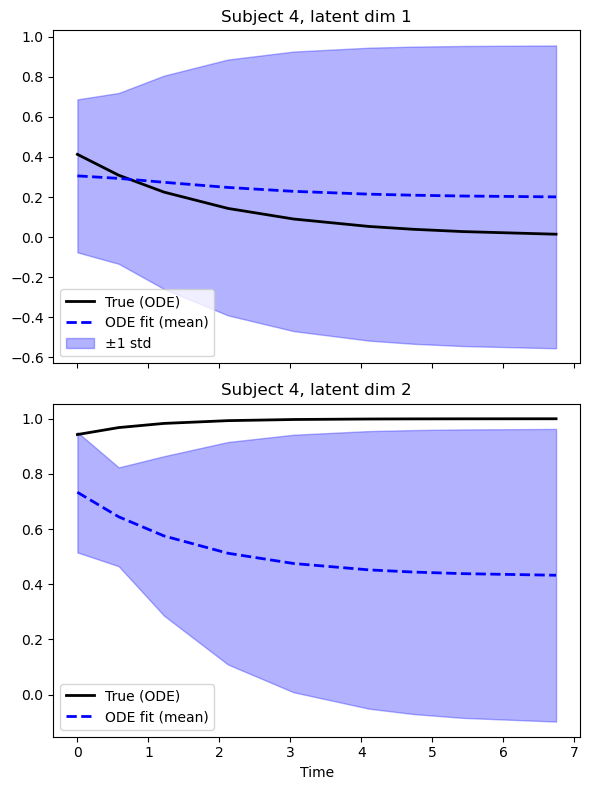

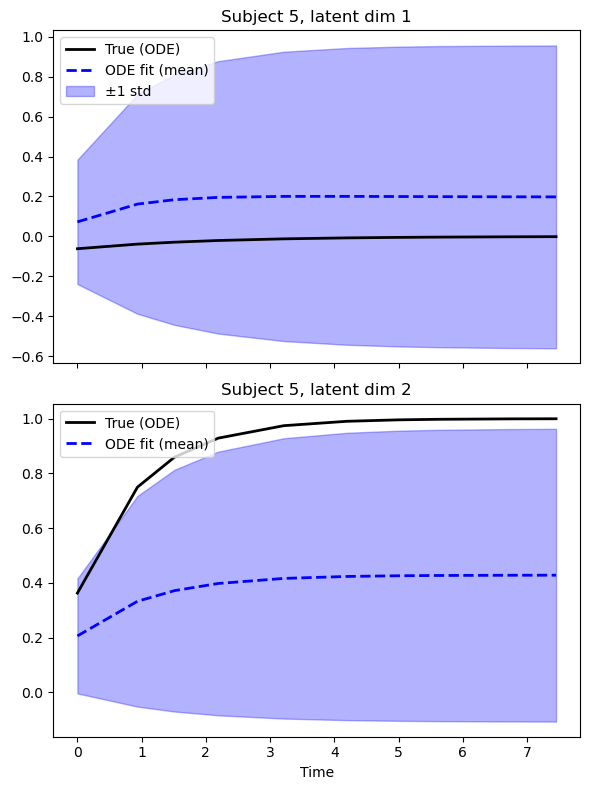

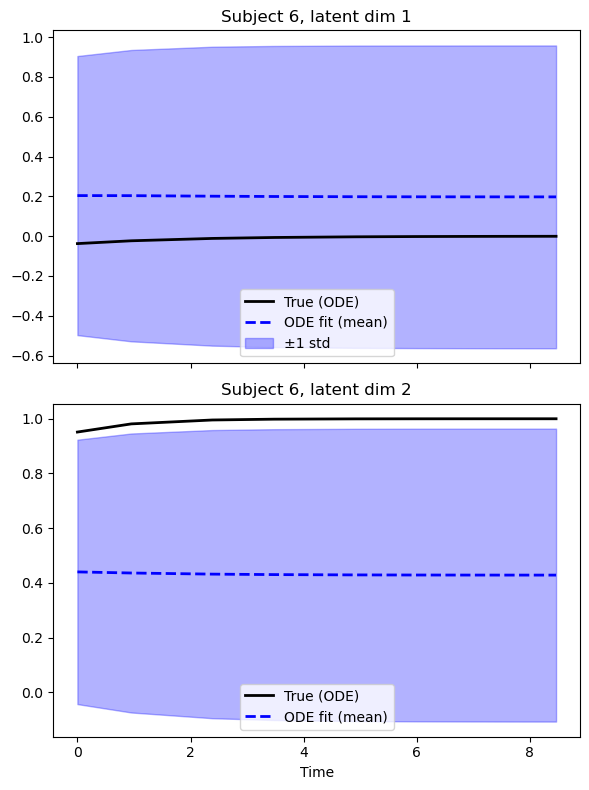

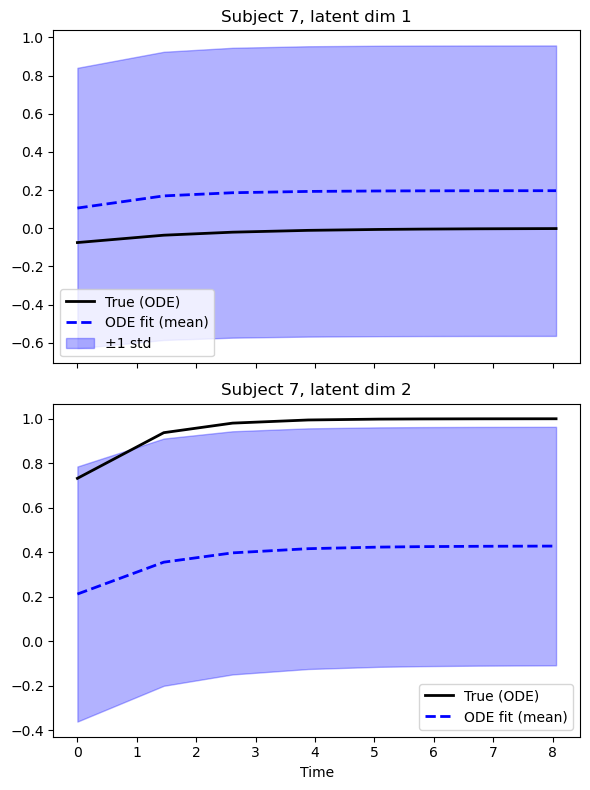

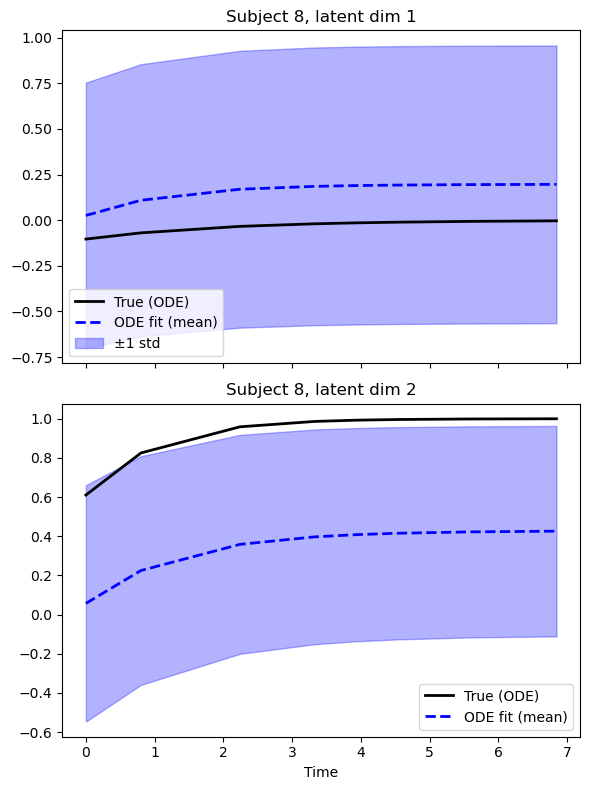

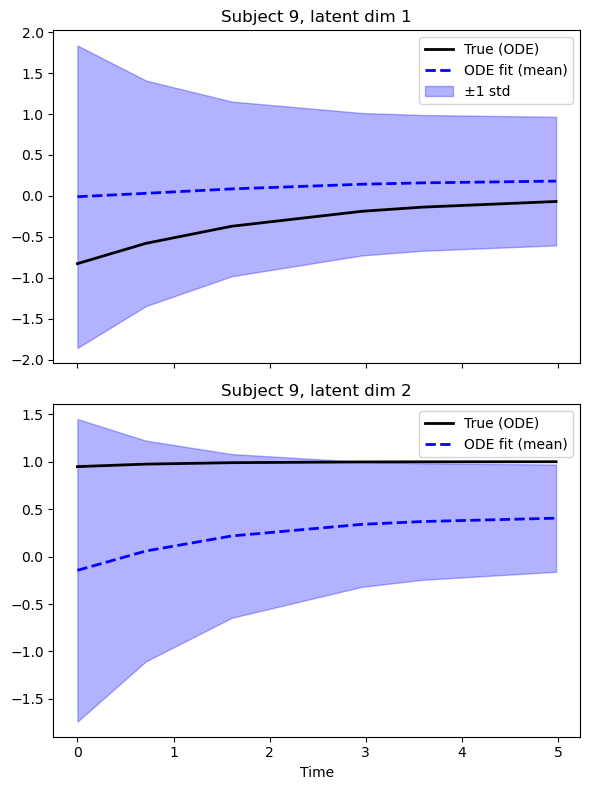

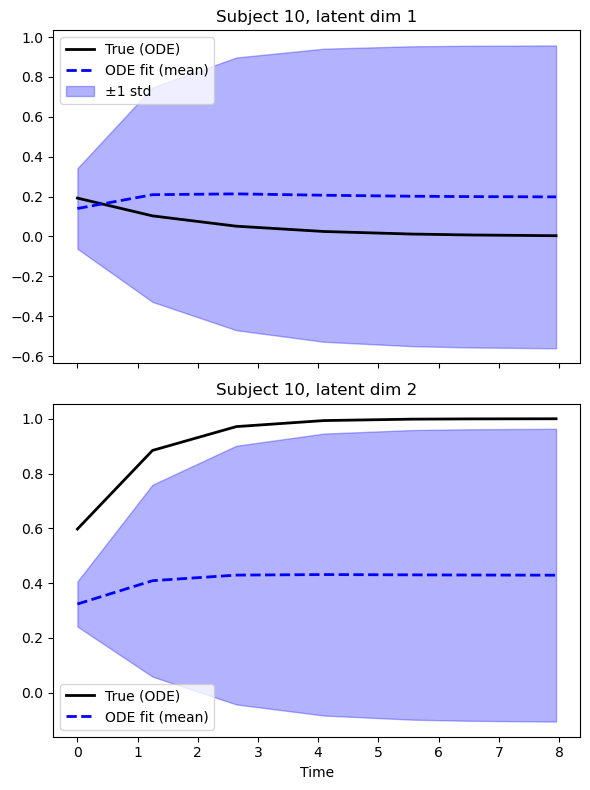

In [14]:
with torch.no_grad():
    for i in range(Nsub):
        T_i = len(t_list[i])
        t_i = t_list[i]

        # Collect trajectories from all runs
        x_est_runs = []

        for model in models:
            x_est_i = estimate_latent_trajectory(
                model,
                i,
                t_torch[i]
            )
            x_est_runs.append(x_est_i)

        # Shape: (n_runs, T_i, K)
        x_est_runs = torch.stack(x_est_runs).cpu().numpy()

        # Mean and variance
        x_mean = x_est_runs.mean(axis=0)
        x_std  = x_est_runs.std(axis=0)

        x_true = x_list[i]

        fig, axes = plt.subplots(K, 1, figsize=(6, 4 * K), sharex=True)

        if K == 1:
            axes = [axes]

        for k in range(K):
            # True latent (OU)
            axes[k].plot(
                t_i,
                x_true[:, k],
                'k-',
                lw=2,
                label="True (ODE)"
            )

            # Mean estimate
            axes[k].plot(
                t_i,
                x_mean[:, k],
                'b--',
                lw=2,
                label="ODE fit (mean)"
            )

            # Variance / CI shading
            axes[k].fill_between(
                t_i,
                x_mean[:, k] - x_std[:, k],
                x_mean[:, k] + x_std[:, k],
                color='blue',
                alpha=0.3,
                label="±1 std" if k == 0 else None
            )

            axes[k].set_title(
                f"Subject {i+1}, latent dim {k+1}"
            )
            axes[k].legend()

        axes[-1].set_xlabel("Time")
        plt.tight_layout()
        plt.show()



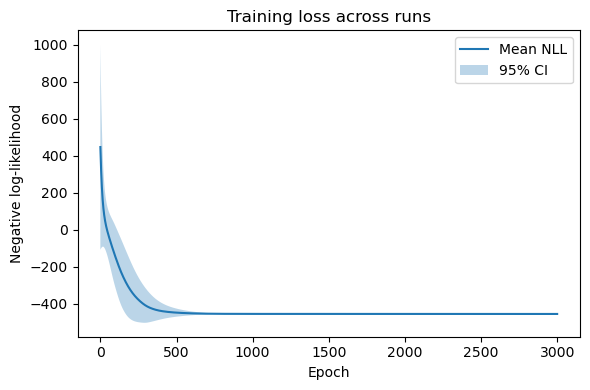

In [15]:
import matplotlib.pyplot as plt

mean_loss = loss_curves.mean(axis=0)
std_loss = loss_curves.std(axis=0)

plt.figure(figsize=(6,4))
plt.plot(mean_loss, label="Mean NLL")
plt.fill_between(
    np.arange(len(mean_loss)),
    mean_loss - 1.96 * std_loss,
    mean_loss + 1.96 * std_loss,
    alpha=0.3,
    label="95% CI"
)
plt.xlabel("Epoch")
plt.ylabel("Negative log-likelihood")
plt.legend()
plt.title("Training loss across runs")
plt.tight_layout()
plt.show()
